In [1]:
#Importing libraries
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import ast
import seaborn as sns

#Loading data
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset['train'].to_pandas()

#Data cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

d:\Anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [49]:
# Filter the dataset for jobs located in US and create a deep copy to avoid SettingWithCopy warnings
df_US = df[(df['job_country'] == 'United States') & (df['job_title_short'] == 'Data Analyst')].copy()

# Define a function to unify salary data into a single annual figure
def combine_salaries(row):
    if pd.notna(row['salary_year_avg']):
        return row['salary_year_avg']
    
    # Check for hourly salary and convert to annual (assuming 40 hours/week, 52 weeks/year)
    # NOTE: Changed your 'elif' from 'salary_year_avg' to 'salary_hour_avg' to fix the logic
    elif pd.notna(row['salary_hour_avg']):
        return row['salary_hour_avg'] * 52 * 40
    else:
        return None

# Apply the conversion function across every row (axis=1) to create the new combined salary column
# Note: Use df_US.apply here to ensure you are mapping against the filtered US data
df_US['yearly_salary_combined'] = df_US.apply(combine_salaries, axis=1)

# Display the final cleaned DataFrame
df_US

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,yearly_salary_combined
36,Data Analyst,Data Analyst,"Des Moines, IA",via Trabajo.org,Full-time,False,"Illinois, United States",2023-11-06 13:01:22,False,True,United States,None,NaN,NaN,Assuredpartners,None,None,NaN
68,Data Analyst,Sr. Research Data Analyst,"Baltimore, MD",via ZipRecruiter,Full-time,False,"New York, United States",2023-03-24 13:01:00,False,False,United States,None,NaN,NaN,Johns Hopkins Medicine,"[r, zoom]","{'programming': ['r'], 'sync': ['zoom']}",NaN
73,Data Analyst,Entry level / Systems Data Analyst (Remote),Anywhere,via LinkedIn,Contractor,True,"Illinois, United States",2023-06-16 13:18:22,True,True,United States,None,NaN,NaN,Soft Magic,"[word, excel, powerpoint, outlook]","{'analyst_tools': ['word', 'excel', 'powerpoin...",NaN
79,Data Analyst,Data Analyst/Report Writer,"Austin, TX",via Jobs Trabajo.org,Full-time,False,"Texas, United States",2023-08-07 13:18:27,True,False,United States,None,NaN,NaN,Nesco Resource,"[sas, sas, word, excel]","{'analyst_tools': ['sas', 'word', 'excel'], 'p...",NaN
93,Data Analyst,IT Finance / TBM Data Analyst - Remote | WFH,Anywhere,via LinkedIn,Full-time,True,"New York, United States",2023-06-10 13:00:05,False,False,United States,None,NaN,NaN,Get It Recruit - Information Technology,"[oracle, azure, power bi, excel, word, powerpo...","{'analyst_tools': ['power bi', 'excel', 'word'...",NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785603,Data Analyst,Junior Data Analyst,"Santa Monica, CA",via Trabajo.org,Full-time,False,"California, United States",2023-09-12 06:00:50,False,False,United States,None,NaN,NaN,"Ramax Search, Inc.","[sql, vba, python, excel, flow]","{'analyst_tools': ['excel'], 'other': ['flow']...",NaN
785626,Data Analyst,Data Acquisition Associate,"Tarrytown, NY",via Trabajo.org,Full-time,False,"New York, United States",2023-10-29 06:01:29,False,False,United States,None,NaN,NaN,Planet Group,[microsoft teams],{'sync': ['microsoft teams']},NaN
785685,Data Analyst,Data Analyst,"Indianapolis, IN",via Trabajo.org,Full-time,False,"Illinois, United States",2023-07-16 06:01:27,True,False,United States,None,NaN,NaN,"Aara Technologies, Inc","[sql, excel]","{'analyst_tools': ['excel'], 'programming': ['...",NaN
785703,Data Analyst,Data Analyst - CRYPTOGRAPHY - Full-time,Anywhere,via Snagajob,Full-time,True,"Texas, United States",2023-01-28 06:02:55,True,False,United States,None,NaN,NaN,Axelon Services Corporation,None,None,NaN


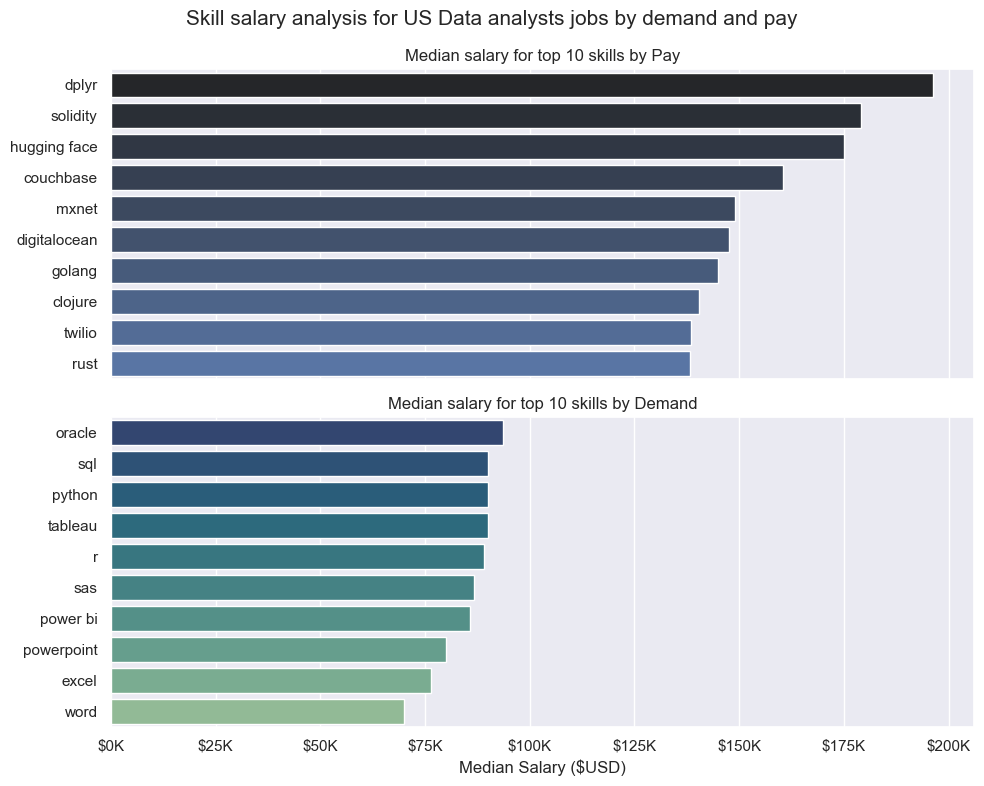

In [51]:
# Flatten the list of skills so each skill has its own row but keeps the associated salary
df_US = df_US.explode('job_skills')

# Group by skill and calculate both the median salary and the count (size) of postings
df_US_skill = df_US.groupby('job_skills')['yearly_salary_combined'].agg(['median', 'size'])

# 2. SUBSETTING
# Get the top 10 highest-paying skills regardless of demand
skills_pay = df_US_skill.sort_values(by='median', ascending=False).head(10)

# Get the top 10 most in-demand skills, then sort them by salary for a cleaner bar chart
skills_demand = df_US_skill.sort_values(by='size', ascending=False).head(10).sort_values(by='median', ascending=False)

# 3. VISUALIZATION
fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
sns.set_theme()

# Top Plot: Highest Paying Skills
sns.barplot(data=skills_pay, x='median', y=skills_pay.index, hue=skills_pay.index, palette='dark:b', ax=ax[0], legend=False)
ax[0].set_title('Median salary for top 10 skills by Pay')
ax[0].set_ylabel('') # Removes redundant index name for cleaner look

# Bottom Plot: Most In-Demand Skills
sns.barplot(data=skills_demand, x='median', y=skills_demand.index, hue=skills_demand.index, palette='crest_r', ax=ax[1], legend=False)
ax[1].set_title('Median salary for top 10 skills by Demand')

# Formatting the X-axis to display as currency ($K)
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))
ax[1].set_xlabel('Median Salary ($USD)')
ax[1].set_ylabel('')

# Final touches
fig.suptitle('Skill salary analysis for US Data analysts jobs by demand and pay', fontsize=15)
plt.tight_layout() # Adjusts spacing to prevent titles/labels from overlapping
plt.show()

In [30]:
skills_pay

,median,size
job_skills,,
pyspark,165000.0,1
linux,165000.0,1
gitlab,165000.0,1
mysql,165000.0,1
postgresql,165000.0,1
mongodb,163782.0,6
gdpr,163782.0,2
neo4j,163782.0,1
databricks,163782.0,3
